In [1]:
'''
필수 의존 라이브러리 (conda prompt 기준)
anaconda prompt 안에서 pip install 진행

1. scanpy lib
pip install scanpy jupyter matplotlib seaborn

2. pooch, leidenalg
pip install scanpy pooch leidenalg

3. Doublet detection시, 사용
pip install scikit-image
'''

'\n필수 의존 라이브러리 (conda prompt 기준)\nanaconda prompt 안에서 pip install 진행\n\n1. scanpy lib\npip install scanpy jupyter matplotlib seaborn\n\n2. pooch, leidenalg\npip install scanpy pooch leidenalg\n\n3. Doublet detection시, 사용\npip install scikit-image\n'

C:\Users\82108\AppData\Local\Temp\ipykernel_21204\1148418568.py:2: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


1.11.5


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


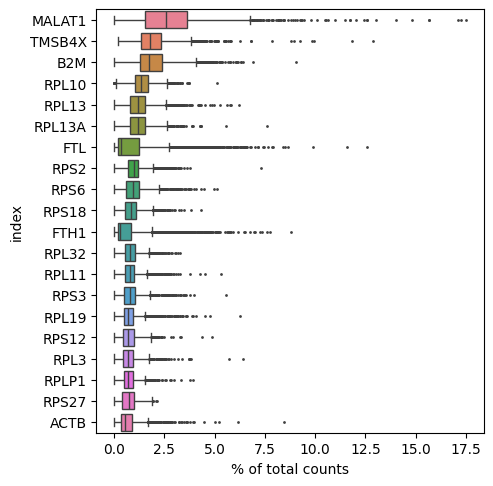

In [2]:
import scanpy as sc
print(sc.__version__)

adata = sc.datasets.pbmc3k()
print(adata)

sc.pl.highest_expr_genes(adata, n_top=20)

### 1. Preprocessing and clustering

해당 데이터는 기본적인 전처리와 클러스터링 튜토리얼로,  NeurIPS 2021 벤치마킹 데이터 셋 중 건강한 사람의 골수 단핵세포 중 일부를 기증 받아서 제작 되었다.

이 샘플은 이 튜토리얼에서 사용되는데 정확히 잰 10X 멀티옴 유전자 발현과 크로마틴 접근성 키트이다.

count matrix를 Anndata 객체로 읽어낸다. 여기에는 데이터의 주석과 다양한 표현 방식을 담는 여러 슬롯을 가지고 있다. 더 자세히 알고싶으면 anndata 튜토리얼 참고

In [3]:
# scverse의 주요 라이브러리
from __future__ import annotations

import anndata as ad

# 데이터 검색
import pooch
import scanpy as sc

sc.settings.set_figure_params(dpi=50, facecolor="white")

In [4]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("scverse_tutorials"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

In [5]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata
    
adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts)
adata

c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names ar

<bound method IndexOpsMixin.value_counts of AAACCCAAGGATGGCT-1    s1d1
AAACCCAAGGCCTAGA-1    s1d1
AAACCCAAGTGAGTGC-1    s1d1
AAACCCACAAGAGGCT-1    s1d1
AAACCCACATCGTGGC-1    s1d1
                      ... 
TTTGTTGAGAGTCTGG-1    s1d3
TTTGTTGCAGACAATA-1    s1d3
TTTGTTGCATGTTACG-1    s1d3
TTTGTTGGTAGTCACT-1    s1d3
TTTGTTGTCGCGCTGA-1    s1d3
Name: sample, Length: 17125, dtype: category
Categories (2, object): ['s1d1', 's1d3']>


AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'

이 데이터는 약 8000개의 세포와 36601개의 측정 된 유전자를 포함한다. 이제 이 기초적인 전처리와 클러스터링 작업과정을 조사해보자.

### Quality Control

`calculate_qc_metrics()` 함수는 일반적인 QC 지표를 계산한다. scater의 `calculateQCMetrics`를 기반으로 한다. 특정 유전자 집단을 함수에 전달하면 해당 집단의 카운트 비율을 계산할 수 있다. 미토콘드리아, 리보솜, 헤모글로빈 유전자는 아래에 나열된 접두사(**prefix**) 로 구분된다.

In [6]:
# mitochondrial genes, "MT-" 접두사라면 사람, "Mt-" 접두사라면 쥐
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [7]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

QC 행렬로 계산 된 violin 구성들을 확인 할 수 있다.

- 행렬 수로 표현 된 유전자의 번호들
- 세포의 총 퍼센트 수
- 미토콘드리아의 퍼센테이지 수

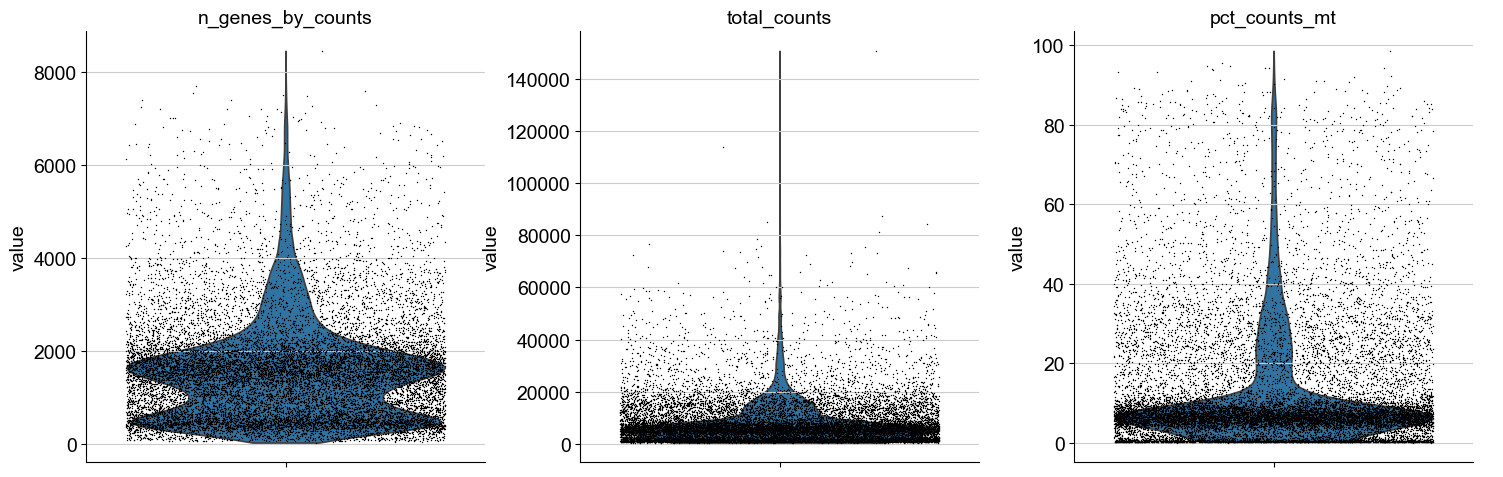

In [8]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

추가적으로 ptc_counts_mt로 색칠 된 산점도 그래프를 검사하는데에는 QC 지표를 함께 보는 것이 더 유용하다.

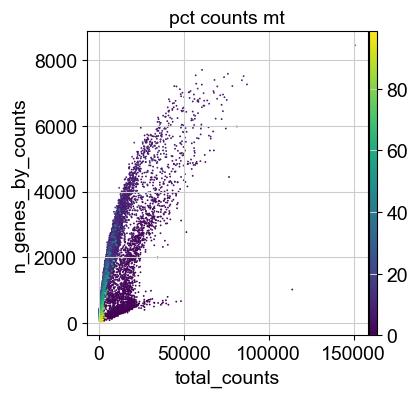

In [9]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

QC지표를 기반으로 세포를 지워야 할때는 너무 많은 미토콘드리이가 표현되어있거나 총 개수가 너무 많다면 지침서 또는 자동 임계값으로 설정한다.

그러나 종종 이상한 QC지표가 실제 생물학적 현상 때문일 수 있으니 전략적으로 매우 허용적인 필터링으로 나중에 다시 검토한다.

그러므로 세포는 100개 이하로 표현하게하고 유전자는 3개 이하로 발견되는 것만 필터링한다.

추가적으로 이것은 데이터셋의 병렬배치에 매우 중요한 메모인데 QC는 임계값을 배치사이에서 상당히 다양하게 개별적으로 수행한다.

In [10]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

## Doublet detection

다음 단계는 Doublet detection 알고리즘이다.

doublet를 식별하는 것은 중요한데, 잘못 된 분류를 하거나 downstream 분석단계에서 왜곡을 유발 할 수 있기 때문이다.

Scanpy는 doublet 탐지 메서드를 가지고있다. Scrublet은 관측된 전사체와 시뮬레이션 된 doublet의 최근접 이웃 분류기를 사용하여 doublet을 예측한다.

*scanpy.pp.scrublet()*는 *doublet_score*과 *predicted_doublet*를 *obs*에 추가한다.
*predicted_doublet*으로 바로 필터링 하거나 *doublet_score*가 나중에 높은 클러스터를 걸러내는 동안 사용할 수 있다.

In [11]:
sc.pp.scrublet(adata, batch_key="sample")

doublet로 판정 된 세포를 바로 필터링하거나, 클러스터링이 끝나고 높은 doublet 스코어를 가진 클러스터를 지우는 방식으로 doublet를 지울 수 있다.

## Normalization

다음 전처리 단계는 정규화이다.

흔한 접근방식은 count depth scaling 후 **log1p** 변환을 적용하는 것이다.
count depth scaling은 데이터를 “size factor”로 정규화하는데, 데이터셋의 중앙값 count depth, **CP10k** 또는 **CPM** 같은거로 한다.
size factor는 *pp.normalize_total* 안의 *target_sum* 울 통해 count depth scaling을 할 수 있다.
깊이 정규화 중앙값 수를 log1p 변환을 통해 나타낸다 (log1PF라고도 불린다).

**log1p = log plus one**
**CP10k = count per ten thousand**
**CPM = count per one million**

In [12]:
# count data 저장하기
adata.layers["counts"] = adata.X.copy()

In [13]:
# 중앙값 total counts를 정규화 하기
sc.pp.normalize_total(adata)
# 데이터 로그 변환
sc.pp.log1p(adata)

### Feature selection

다음 단계는 데이터셋의 차원을 줄이고 가장 유익한 유전자들을 포함하는 것이다.
이 단계에서는 흔하게 아는 feature selection라고 한다.
Scanpy 함수 중에 *pp.highly_variable_gens*는 선택한 *flavor*에 따라 Seurat, Cell Ranger 그리고 Seurat v3의 구현 방식을 재현하여 highly variable gene에 주석을 단다.

In [14]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")

In [15]:
sc.pp.highly_variable_genes(adata)

### Dimensionality Reduction

PCA를 실행하여 데이터의 차원을 줄인다.
PCA는 데이터의 주요 변동 축을 찾고 노이즈를 제거한다.

In [16]:
sc.tl.pca(adata)

각 PC가 전체 분산에 기여하는 정도를 본다.
이를 통해 세포 간 인접한 관계 계산에 몇개의 PC를 고려해야하는지 정보를 준다.
*leiden()*이나 *tsne()* 함수를 클러스터링 할 때 사용한다.
경험적으로 PC수를 과대평가해도 큰 단점은 없는 것으로 보인다.

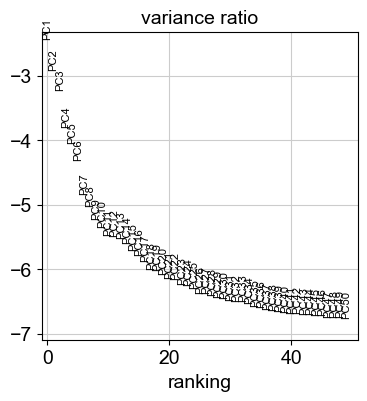

In [17]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

또한 PC plot을 통해 배치나 QC 지표 같은 바람직하지 않은 요인이 데이터셋의 유의미한 변동을 유발하는지 확인 할 수 있다.
이 경우 크게 우려할 만한 것은 없지만 탐색해보는 것이 좋다.

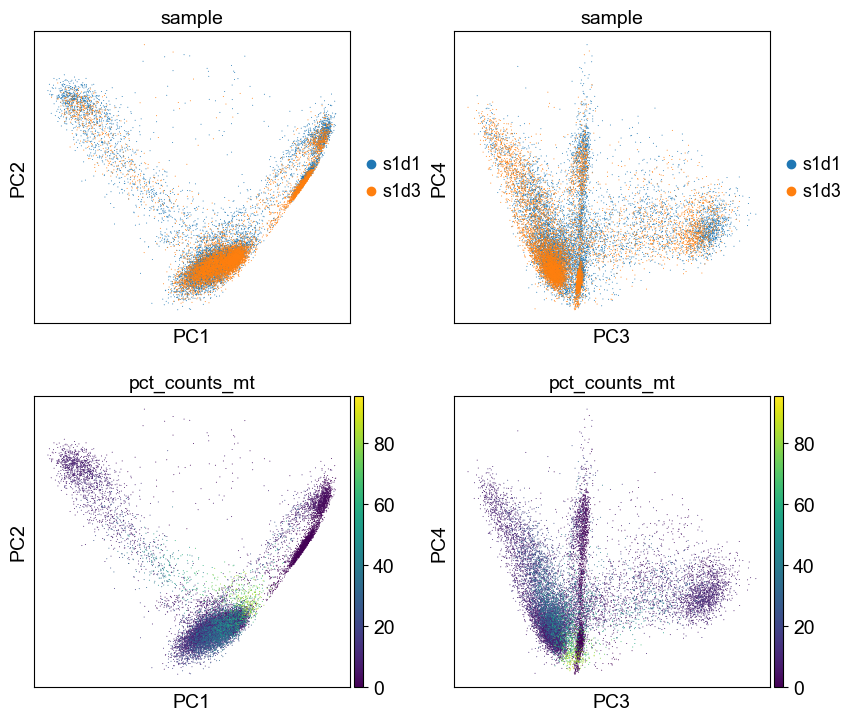

In [18]:
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2
)

## Nearest neighbor graph construction and visualization

데이터 행렬의 PCA 표현을 사용하여 세포간 인접 그래프를 계산해보자.

In [19]:
sc.pp.neighbors(adata)

print(adata)

AnnData object with n_obs × n_vars = 17041 × 23427
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'sample_colors', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'


이 그래프는 UMAP와 통해 보여지기 위해 2차원으로 임베딩하여 시각화 할 수 있다.

In [20]:
sc.tl.umap(adata)

print(f"adata set in umap: {adata.obsm}")

adata set in umap: AxisArrays with keys: X_pca, X_umap


UMAP를 sample에 따라서 시각화 할 수 있다.

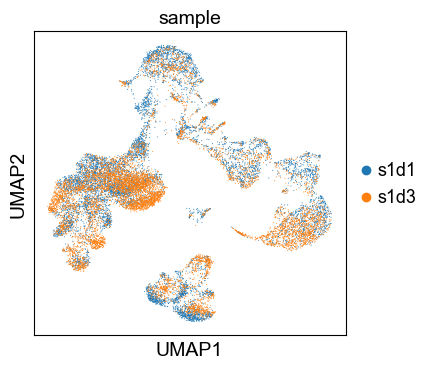

In [21]:
sc.pl.umap(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

그럼에도 불구하고 데이터는 이 튜토리얼에서 두개의 다른 샘플들을 포함하지만
마이너한 배치 효과만 관찰되므로 데이터를 클러스터링하거나 주석을 다는것을 지속한다.

만약 UMAP의 배치효과가 발견된다면 샘플들을 통합 하거나 배치가 맞는지 통합되었는지 수행하는 것이 유익할 것이다.

*scanorama*나 *scvi-tools*를 사용해서 배치 통합을 검사하는 것을 추천한다.

## Clustering

Seurat와 다른 많은 프레임워크들은 Leiden graph-clustering method를 추천한다.
(모듈성 최적화를 기반으로 한 커뮤니티 탐지)

참고로 Leiden clustering directly clusters은 이전 섹션에서 이미 계산한 인접한 세포들의 그래프를 그린다.

In [22]:
# igraph를 사용하여 구현하고 식별을 빨리하고 특히 큰 데이터셋을 처리하기 위해 숫자를 계속해서 고친다
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

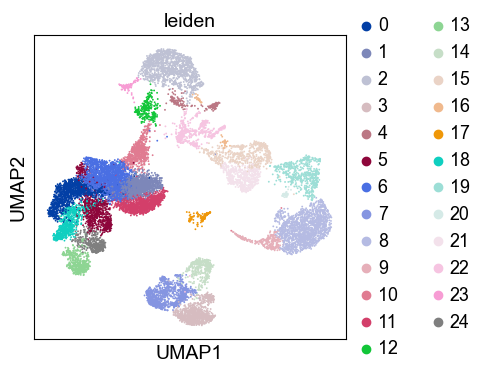

In [23]:
sc.pl.umap(adata, color=["leiden"])

### 해당 plot은 어떻게 저장하나요?

Matplotlib figure를 통하여 바로 저장 가능하다.

'''
sc.pl.umap(adata, color=["leiden"], show).figure.savefig("output_path.ext")
'''

## Re-assess quality control and cell filtering

앞서 언급했듯이 UMAP를 사용하여 시각화 된 여러 QC 행렬의 전략적인 필터링을 재승인 해야한다.

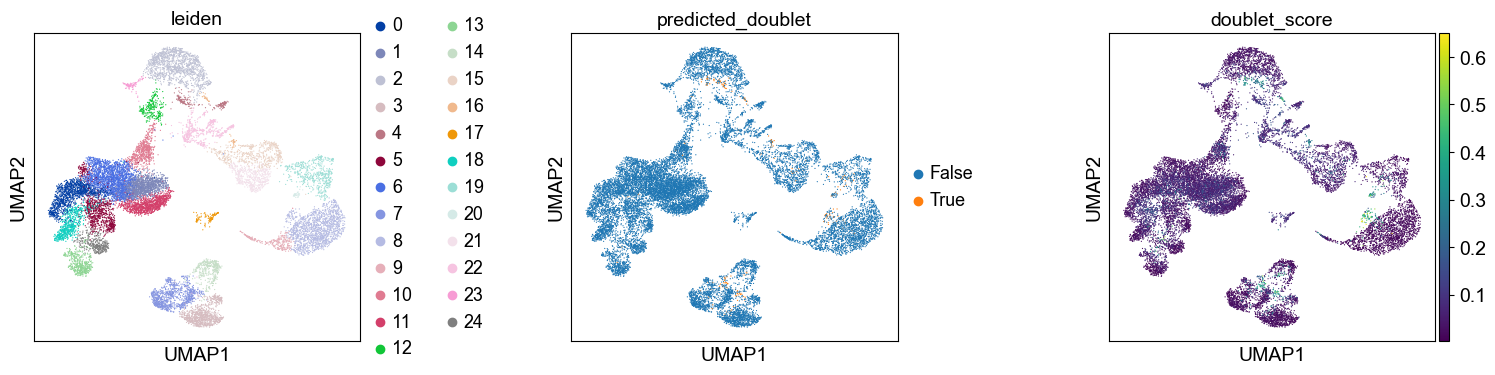

In [24]:
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

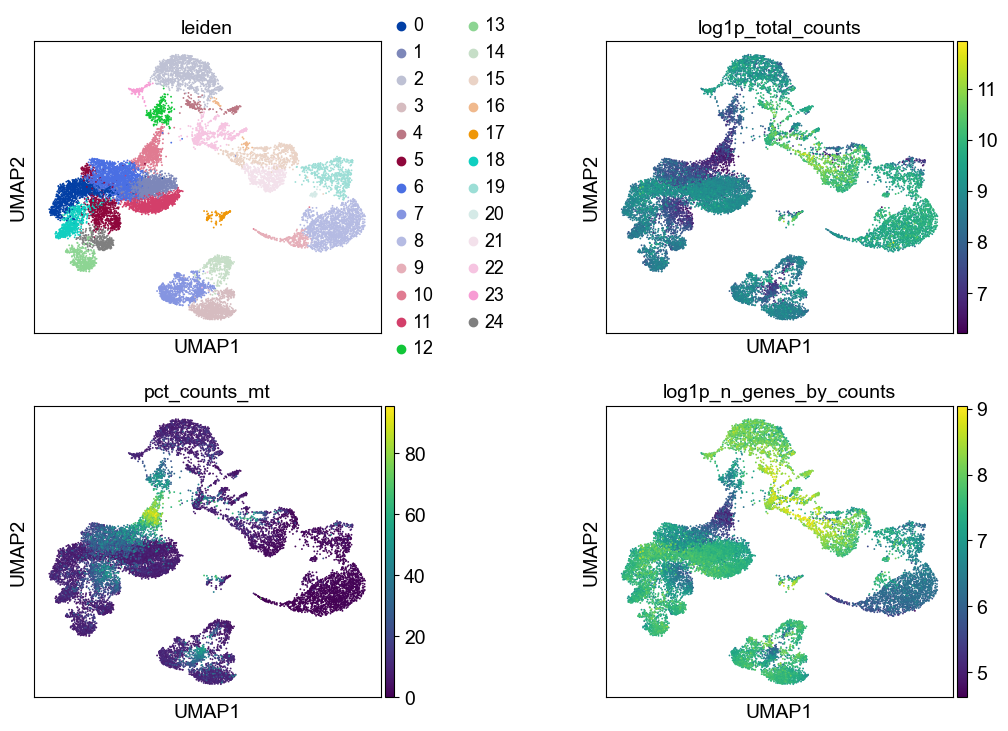

In [25]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

## Manual cell-type annotation

**Note:
튜토리얼의 해당 섹션은 자동화된 주석 부여 및 유전자 enrichment 같은 사전 지식 리소스를 활용하여 확장된 내용이다.**

세포 타입의 주석을 다는 것은 고되고 반복적인 과업으로, 일반적으로 여러 라운드에서 subclustering과 re-annotaion을 요구한다. 이것은 튜토리얼의 진행상황에서 전체적으로 보여주기 어렵지만 우리는 scanpy tool로 어떻게 해당 프로세스를 보조하여 제공할건지 보여주는 것에 초점을 맞추었다.

우리는 괜찮은 퀄리티의 세포를 확보했고 세포 타입의 주석을 달 수 있는 단계에 도달했다.
일반적으로 세포 타입에서만 독점적으로 발현되는 유전자, 이 유전자들이 다른 세포 타입에 마킹되는 것 그리고 데이터에서 세포의 이질적인 그룹을 구별하는데에 유전자를 활용하는 것이 다이다.

이전 연구들을 통해 다양한 marker gene이 수집 및 정제되어 CellMarker나 TF-Marker그리고 PanglaoDB의 리소스로 활용 가능하다.

cellxgene gene expression tool은 많이 존재하는 데이터셋들을 표현할 때 어떤 세포 타입의 유전자인지 볼 경우 아주 유용하다.

일반적으로 클러스터링 된 세포들을 그룹핑한 다음 세포 타입의 유전자를 마킹 하는데에 사용 된다. 그래서 보편적으로 세포 타입을 정의하는 주석을 사용하여 클러스터링 솔루션을 정한다.
인접 분포 그래프에서 세포 커뮤니티를 추출 하는데 Leiden clustering algorithm을 사용한다.

In [26]:
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

특히 클러스터 번호를 매기는 것은 임의로 큰것을 정의하기에 resolution 파라미터를 사용하여 제어 가능하다. 따라서 클러스터로 번호를 매기는 것은 궁극적으로 구역을 정하고 해당 구역이나 마커 형태로 전문가가 선별한 사전 지식을 사용하여 독특하고 다양한 전문가들 생물학적으로 의미있는 그룹이다.

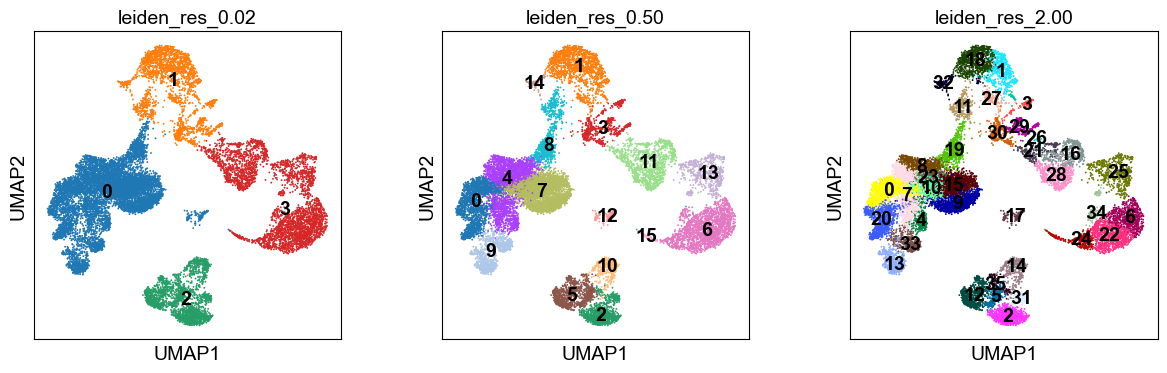

In [27]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)

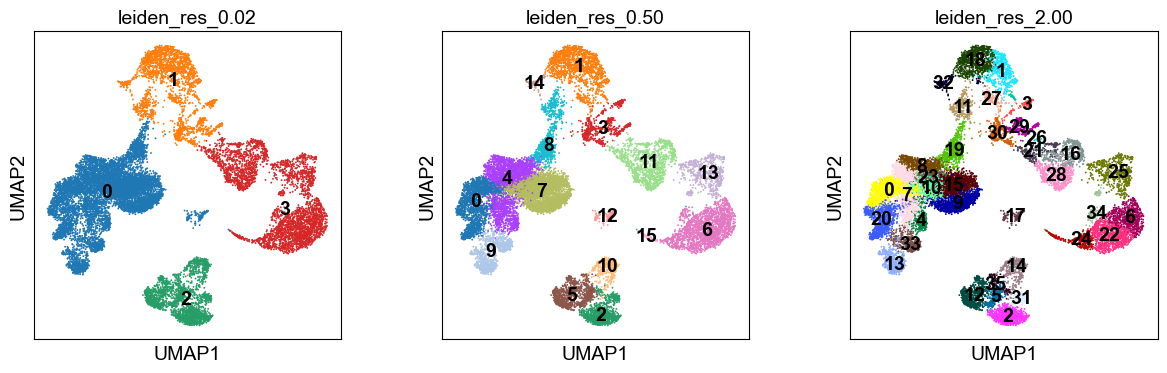

In [28]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)

UMAP는 과다 번역하지 않는다.
여기 준비 된 데이터 중 오버 클러스터링 된 것들 중 가장 높은 수치의 결과물을 보면, 낮은 결과물은 가까운 세포들의 식별자가 그룹핑 된 세포들과 같다.

## Marker gene set
데이터셋에 나타나있는 marker gens의 주된 세포 타입들을 정의해보자.
Single Cell Best Practice 주석 챕터에 연결되어있다.
